# **Red Neuronal LSTM**

In [ ]:
# Procesamiento de datos
import yfinance as yf
import numpy as np
import pandas as pd
import math
# Representación de datos
import matplotlib.pyplot as plt
from tabulate import tabulate
# Red Neuronal LSTM
from keras.models import Sequential
from keras.layers import LSTM, Dense
# Medidas del error
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [ ]:
# Función creada que convierte los datos de entrada en (i,j)
def convert2matrix(data_arr, look_back):
 X, Y =[], []
 for i in range(len(data_arr)-look_back):
  d=i+look_back
  X.append(data_arr[i:d])
  Y.append(data_arr[d])
 return np.array(X), np.array(Y)

In [ ]:
empresas = [
    'TSLA', #Tesla
    'GOOG', #Google
    'META', #Meta
    'AMZN', #Amazon
    'MSFT', #Microsoft
    'AAPL', #Apple
]
# Indicar el tipo de volatilidad a predecir en td como:
# 'D' --> Dayly (Diaria) 'W' --> Weekly (Semanal) 'M' --> Monthly (Mensual)
td = 'M'
if (td == 'D'):
  dtime = 'diaria'
  test_size = 150
elif (td == 'W'):
   dtime = 'semanal'
   test_size = 100
else:
  dtime = 'mensual'
  test_size = 50
# Indicar el tamaño de la ventana
N = 50

[*********************100%%**********************]  1 of 1 completed
0
Epoch 1/20
9/9 [==============================] - 7s 161ms/step - loss: 162.5875 - val_loss: 375.4736
Epoch 2/20
9/9 [==============================] - 0s 10ms/step - loss: 154.1953 - val_loss: 361.4889
Epoch 3/20
9/9 [==============================] - 0s 9ms/step - loss: 146.1791 - val_loss: 347.2788
Epoch 4/20
9/9 [==============================] - 0s 9ms/step - loss: 138.1977 - val_loss: 332.6410
Epoch 5/20
9/9 [==============================] - 0s 10ms/step - loss: 130.1057 - val_loss: 318.0660
Epoch 6/20
9/9 [==============================] - 0s 10ms/step - loss: 121.6527 - val_loss: 303.3709
Epoch 7/20
9/9 [==============================] - 0s 8ms/step - loss: 113.4127 - val_loss: 287.7654
Epoch 8/20
9/9 [==============================] - 0s 9ms/step - loss: 104.9681 - val_loss: 272.9763
Epoch 9/20
9/9 [==============================] - 0s 9ms/step - loss: 97.6879 - val_loss: 257.8902
Epoch 10/20
9/9 [========

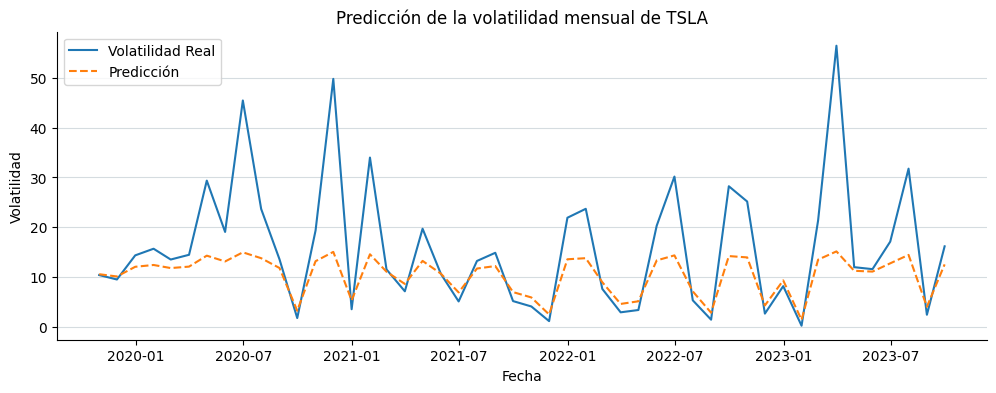

[*********************100%%**********************]  1 of 1 completed
0
Epoch 1/20
9/9 [==============================] - 3s 72ms/step - loss: 32.0421 - val_loss: 72.5435
Epoch 2/20
9/9 [==============================] - 0s 9ms/step - loss: 29.7537 - val_loss: 66.9709
Epoch 3/20
9/9 [==============================] - 0s 8ms/step - loss: 27.6194 - val_loss: 61.5963
Epoch 4/20
9/9 [==============================] - 0s 9ms/step - loss: 25.6062 - val_loss: 56.3452
Epoch 5/20
9/9 [==============================] - 0s 8ms/step - loss: 23.7535 - val_loss: 51.2434
Epoch 6/20
9/9 [==============================] - 0s 10ms/step - loss: 22.0291 - val_loss: 46.8250
Epoch 7/20
9/9 [==============================] - 0s 9ms/step - loss: 20.5095 - val_loss: 42.8929
Epoch 8/20
9/9 [==============================] - 0s 9ms/step - loss: 19.3236 - val_loss: 39.1748
Epoch 9/20
9/9 [==============================] - 0s 8ms/step - loss: 18.3519 - val_loss: 36.2529
Epoch 10/20
9/9 [============================

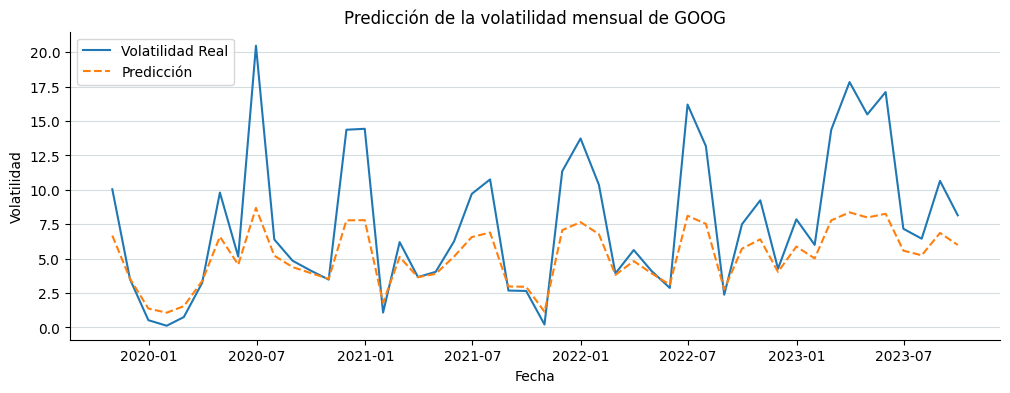

[*********************100%%**********************]  1 of 1 completed
0
Epoch 1/20
9/9 [==============================] - 3s 71ms/step - loss: 104.5307 - val_loss: 131.3368
Epoch 2/20
9/9 [==============================] - 0s 10ms/step - loss: 99.2344 - val_loss: 125.5906
Epoch 3/20
9/9 [==============================] - 0s 11ms/step - loss: 94.2499 - val_loss: 120.0038
Epoch 4/20
9/9 [==============================] - 0s 9ms/step - loss: 89.0295 - val_loss: 114.5921
Epoch 5/20
9/9 [==============================] - 0s 10ms/step - loss: 83.9327 - val_loss: 109.0965
Epoch 6/20
9/9 [==============================] - 0s 9ms/step - loss: 79.2032 - val_loss: 103.2433
Epoch 7/20
9/9 [==============================] - 0s 9ms/step - loss: 73.9951 - val_loss: 97.8742
Epoch 8/20
9/9 [==============================] - 0s 8ms/step - loss: 69.7815 - val_loss: 92.1330
Epoch 9/20
9/9 [==============================] - 0s 9ms/step - loss: 64.8865 - val_loss: 86.9416
Epoch 10/20
9/9 [===================

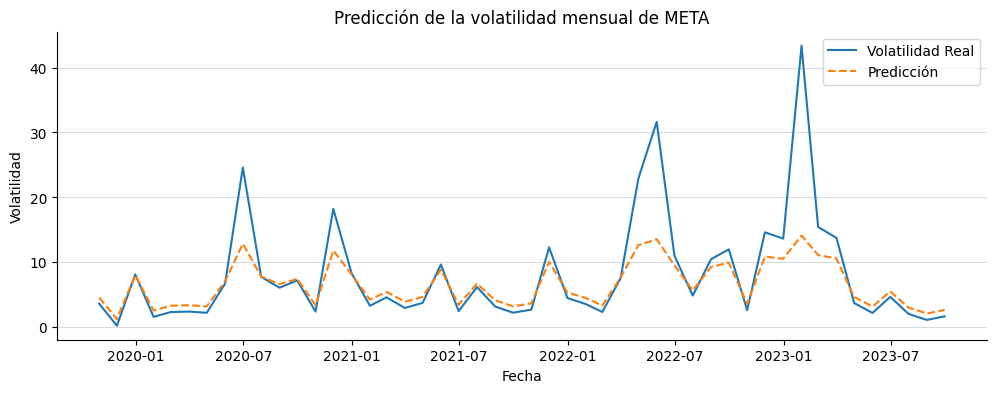

[*********************100%%**********************]  1 of 1 completed
0


KeyboardInterrupt: ignored

In [ ]:
# BLOQUE PRINICPAL
rent = pd.DataFrame()
# Recopilamos los datos de Yahoo Finance
for emp in empresas:
  ticker= emp
  data = yf.download(ticker, start="2012-05-30", end="2023-09-30")
  # Calculamos los rendimientos logarítmicos diarios y volatilidad
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent= data['R_Log'].resample(td).sum()
  rentabilidad = rent.replace(0.000000, np.nan).dropna()
  vol = rentabilidad.rolling(window=2).std().dropna()
  # BLOQUE DE PREDICCIÓN
  # Separamos los datos de entrenamiento y de prueba
  roll_pred = []
  for i in range(0,test_size,N):
    print(i)
    train = vol[i:-(test_size-i)]
    if (i == test_size-N):
      test = vol[-(test_size-i):]
    else:
      test = vol[-(test_size-i):-(test_size-(i+N+1))]
    # Transformamos los datos en matriz 3D
    X = train.dropna()
    X = X.values
    T = test.dropna()
    T = T.values
    xtrain, ytrain = convert2matrix(X,1)
    xtest, ytest = convert2matrix(T,1)
    X_train = xtrain.reshape(xtrain.shape[0],xtrain.shape[1],1)
    Y_train = ytrain
    X_test = xtest.reshape(xtest.shape[0],xtest.shape[1],1)
    Y_test = ytest
    # Definimos y entrenamos el modelo
    model = Sequential()
    model.add(LSTM(128, input_shape=(X_train.shape[1],1), activation='tanh')) # 4, 8, 16, 32, 64
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', )
    model.fit(X_train, Y_train, epochs=20 ,batch_size = 10, validation_data=(X_test, Y_test))
    # Predecimos lo valores de prueba con el modelo LSTM
    pred = model.predict(X_test)
    roll_pred.extend(pred)
  predictions = [array[0] for array in roll_pred]
  predictions = pd.Series(predictions, index=vol.index[-test_size+1:])
  predictions = predictions.dropna() # Nos aseguramos que los índices coincidan
  vol_moved = vol[-test_size:].shift(1).dropna()
  predictions =  predictions.shift(1).dropna()
  # Calculamos el error
  mse = mean_squared_error(predictions, vol_moved[:-1])
  rmse = np.sqrt(mse)
  mape = np.mean(mean_absolute_percentage_error(predictions, vol_moved[:-1]))
  print(tabulate([[ticker,mse,rmse,mape]],
                headers = ['MSE', 'RMSE', 'MAPE'],
                tablefmt = 'fancy_grid',stralign='center',numalign='center',floatfmt=".4f"))
  # Graficamos los valores predichos con los reales
  fig,ax = plt.subplots(figsize=(12,4))
  ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
  ax.spines[['top', 'right']].set_visible(False)
  plt.plot(vol_moved.index[-test_size+2:], vol_moved[:-1], label='Volatilidad Real')
  plt.plot(predictions, linestyle='--', label = 'Predicción')
  plt.title(f'Predicción de la volatilidad {dtime} de {ticker}')
  plt.xlabel('Fecha')
  plt.ylabel('Volatilidad')
  plt.legend()
  plt.show()

## **Experimentación y estimación parámetros óptimos**

In [ ]:
# Experimentación de nivel de neuronas, epochs y función de activación
Units = [2,4,8,16,32,64,128] # u
Ep = [5,10,15,20,25,30] # e
FA = ['tanh','sigmoid','relu'] # f
BSize = [5,10,15,20,25,30]
vol_moved = vol[-test_size:].shift(1).dropna()
fig,ax = plt.subplots(figsize=(13,4))
ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
ax.spines[['top', 'right']].set_visible(False)
plt.plot(Y_test,label='Volatilidad Real')
for u in Units:
  model = Sequential()
  model.add(LSTM(u, input_shape=(X_train.shape[1],1), activation=FA[0]))
  model.add(Dense(1))
  model.compile(loss='mse', optimizer='adam', )
  model.fit(X_train, Y_train, epochs=Ep[3], batch_size=10 ,validation_data=(X_test, Y_test))
  pred = model.predict(X_test)
  # Calculamos RMSE y MAPE
  mse = mean_squared_error(pred, Y_test)
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(pred,Y_test)
  print(tabulate([[ticker,mse,rmse,mape]],
                headers = ['MSE', 'RMSE', 'MAPE %'],
                tablefmt = 'fancy_grid',stralign='center',numalign='center',floatfmt=".4f"))
  plt.plot(pred, linestyle='--', label = f'Predicción ({u})')
plt.xlabel('Muestras')
plt.ylabel('Volatilidad')
plt.legend()
plt.show()